# Construction attributes and exposure tolerance

This notebook reproduces the construction-attribute results and publication Table 1. The main estimands are exposure-tolerance ratios: the multiple of realized coupling associated with the same modeled outcome probability. Values above one indicate greater tolerance.

**Manuscript link:** Results, *Construction attributes*. The main table reports overall destruction and the continuation-ratio decomposition into damage onset and escalation. Attribute misengness, spline specifications, fire-specific models, alternative up-fire exposure, and exposure-interaction diagnostics belong in `extended_data/ED03_construction_sensitivity.ipynb`.

In [17]:
import json
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import Markdown, display

from src.analysis.construction import (
    attribute_unknownness_by_outcome, cross_fire_standardization, fit_damage_stages,
    fit_overall_attributes, prepare_construction_samples,
    publication_table_markdown,
)
from src.analysis.population_audit import sha256

DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)
N_BOOT = 200
BOOTSTRAP_SEED = 20250729

## Population and attribute scaling

*Neither — analysis population and sample ladder.*

The analysis is restricted to structures with $F^*>0$ and excludes documented defense. Roof and vegetation estimates use structures with known roof material. Building-vintage and stage models additionally require construction year. Vegetation is scaled to one interquartile-range increase and construction year to one decade.

In [18]:
manifest = json.loads((RESULTS / 'analysis_manifest.json').read_text())
analysis_path = DATA / 'analysis.parquet'
assert sha256(analysis_path) == manifest['inputs']['analysis']['sha256']
analysis = pd.read_parquet(analysis_path)
samples = prepare_construction_samples(analysis)
sample_flow = pd.DataFrame([
    {'population': 'Assessed structures', 'n': len(analysis)},
    {'population': 'Exposed structures (F* > 0)', 'n': len(samples.exposed)},
    {'population': 'Exposed and undefended', 'n': len(samples.undefended)},
    {'population': 'Undefended with known roof', 'n': len(samples.known_roof)},
    {'population': 'Complete roof, vegetation and vintage', 'n': len(samples.complete)},
    {'population': 'Complete and damaged (escalation)',
     'n': int(samples.complete.any_damage.sum())},
])
sample_flow.to_csv(RESULTS / 'construction_sample_flow.csv', index=False)
display(sample_flow)
print(f'NDVI IQR = {samples.ndvi_iqr:.4f}')
print(f'Construction year centered at {samples.year_reference:.0f}; reported per decade')

,population,n
0,Assessed structures,28208
1,Exposed structures (F* > 0),25127
2,Exposed and undefended,23835
3,Undefended with known roof,21831
4,"Complete roof, vegetation and vintage",21288
5,Complete and damaged (escalation),13907


NDVI IQR = 0.1370
Construction year centered at 1949; reported per decade


## Post-fire attribute-recording audit

*Supplement — Supplementary Table S1.*

Eaves, vent screening and window panes can become unobservable when a structure is destroyed. Unknown-recording rates are therefore compared between destroyed structures and structures that survived, including undamaged and partially damaged buildings. This audit uses all 28,208 assessed structures because it evaluates DINS data availability rather than an exposure-response estimand. Strong outcome-dependent misengness precludes interpreting these fields as pre-fire construction attributes. Exterior siding is included for comparison but is also excluded from inference because the material remaining after fire may not represent the pre-fire assembly.

In [19]:
attribute_recording = attribute_unknownness_by_outcome(analysis)
attribute_recording.to_csv(
    RESULTS / 'tableS_attribute_recording_by_outcome.csv', index=False
)
display(attribute_recording[[
    'attribute', 'survived_n', 'survived_unknown_n',
    'survived_unknown_percent', 'destroyed_n', 'destroyed_unknown_n',
    'destroyed_unknown_percent', 'difference_percentage_points',
]].round(1))

,attribute,survived_n,survived_unknown_n,survived_unknown_percent,destroyed_n,destroyed_unknown_n,destroyed_unknown_percent,difference_percentage_points
0,Eaves,13101,46,0.4,15107,10747,71.1,70.8
1,Vent screening,13101,457,3.5,15107,6713,44.4,40.9
2,Window panes,13101,77,0.6,15107,6769,44.8,44.2
3,Exterior siding,13101,18,0.1,15107,614,4.1,3.9


## Table 1a — Overall destruction

*Superseded — retained for comparison with the published analysis.*

Logistic models adjust for log $F^*$ and fire. Roof and vegetation are mutually adjusted. The vintage model additionally includes continuous construction year. Attribute coefficients are converted to exposure-tolerance ratios using $\exp(-\gamma/\beta)$, where $\gamma$ is the attribute coefficient and $\beta$ is the log-exposure coefficient.

In [20]:
overall_table, overall_raw, overall_models = fit_overall_attributes(samples)
overall_table.to_csv(RESULTS / 'table1a_construction_overall.csv', index=False)
display(overall_table[[
    'attribute', 'contrast', 'analysis_n', 'tolerance_ratio',
    'ci_lo', 'ci_hi', 'p_value',
]].round(4))

,attribute,contrast,analysis_n,tolerance_ratio,ci_lo,ci_hi,p_value
0,Tile roof,Tile versus asphalt,21831,1.2932,1.1514,1.4526,0.000
1,Near-structure vegetation,Per IQR increase in NDVI,21831,0.7120,0.6633,0.7641,0.000
2,Building vintage,Per decade newer,21288,1.0356,1.0108,1.0609,0.004


## Table 1b — Damage onset and escalation

*Superseded — retained for comparison with the published analysis.*

Onset is any recorded damage among exposed structures. Escalation is destruction conditional on having sustained damage. Both models contain roof, vegetation, continuous building vintage, log exposure and fire. A stacked model tests whether each association differs between stages. Escalation estimates condition on an observed outcome and are interpreted descriptively.

In [21]:
stage_table, stage_raw, stage_models = fit_damage_stages(samples)
stage_table.to_csv(RESULTS / 'table1b_construction_stages.csv', index=False)
display(stage_table.round(4))

,attribute,contrast,onset_n,onset_tolerance_ratio,onset_ci_lo,onset_ci_hi,onset_p_value,escalation_n,escalation_tolerance_ratio,escalation_ci_lo,escalation_ci_hi,escalation_p_value,stage_difference_p_value
0,Tile roof,Tile versus asphalt,21288,1.2711,1.1187,1.4443,0.0002,13907,1.2335,0.9099,1.6723,0.174,0.2188
1,Near-structure vegetation,Per IQR increase in NDVI,21288,0.7951,0.7400,0.8544,0.0000,13907,0.5474,0.4556,0.6578,0.000,0.0416
2,Building vintage,Per decade newer,21288,0.9995,0.9742,1.0255,0.9723,13907,1.1380,1.0667,1.2140,0.000,0.0004


## Fitted models

*Neither — fits and diagnostics feeding every table and figure below.*

Three specifications are fitted, as a nested ladder on one estimation sample:
exposed structures with a known roof class, positive NDVI and a positive
boundary distance, with defended structures retained. Model (1) carries roof
material as a class, vegetation as continuous $\log(\mathrm{NDVI})$, log
realized coupling and fire. Model (2) adds distance to the cleaned,
fire-clipped CAL FIRE Influence boundary and an indicator for documented
defense at the property. Model (3) adds the interactions of log realized
coupling with roof class, vegetation, distance and defense, testing whether
those associations depend on the level of exposure.

The boundary distance reproduces the ED02 urban-depth construction, a 100 m
morphological opening of the perimeter-clipped Influence Zone followed by the
shortest distance from each building's representative point, computed here so
this notebook does not depend on ED02 having been run. Continuous predictors
are centered at their sample means, which leaves every slope unchanged but
evaluates the main effects of model (3) at mean exposure rather than at
$F^*=1$, a value outside the data. Each added block is tested jointly with a
Wald test on the cluster-robust covariance rather than a likelihood-ratio
test, which clustering would invalidate. Every term is exported with its
coefficient, cluster-robust standard error, $z$ statistic, $P$ value, 95%
confidence interval and odds ratio, and the statsmodels report is printed for
each fit.

In [24]:
import duckdb
import geopandas as gpd
import numpy as np
import shapely

from src.analysis.construction import ROOF_TERM, TILE_TERM, fit_clustered_logit

M_TO_FT = 3.28084
INFLUENCE_OPENING_M = 100.0  # shrink then expand to remove narrow slivers

# Distance to the cleaned, fire-clipped CAL FIRE Influence boundary, rebuilt
# here with the construction used in ED02 so this notebook stays self-contained.
wui_zones = gpd.read_file(DATA / 'calfire_wui_la.gpkg').to_crs(26911)
influence_zone = wui_zones[wui_zones.WUI_DESC.eq('Influence Zone')]
fire_perimeters = (gpd.read_parquet(DATA / 'nx' / 'fire_perims.parquet')
                   .to_crs(26911).set_index('FIRE_NAME'))
depth_parts = []
for fire_name in ['EATON', 'PALISADES']:
    buildings = gpd.read_parquet(
        DATA / 'nx' / f'{fire_name}_buildings.parquet',
        columns=['BLD_ID', 'geometry']).to_crs(26911)
    buildings['BLD_ID'] = buildings.BLD_ID.astype(str)
    buildings = buildings.drop_duplicates('BLD_ID').reset_index(drop=True)
    clipped = shapely.intersection(influence_zone.geometry.union_all(),
                                   fire_perimeters.loc[fire_name].geometry)
    opened = shapely.buffer(shapely.buffer(clipped, -INFLUENCE_OPENING_M),
                            INFLUENCE_OPENING_M)
    boundary_parts = (gpd.GeoSeries([opened], crs=26911).boundary
                      .explode(index_parts=False).reset_index(drop=True))
    points = buildings.geometry.representative_point().to_numpy()
    nearest = boundary_parts.sindex.nearest(
        gpd.GeoSeries(points, crs=26911), return_all=False)
    nearest_part = np.empty(len(buildings), dtype=int)
    nearest_part[nearest[0]] = nearest[1]
    depth_parts.append(pd.DataFrame({
        'BLD_ID': buildings.BLD_ID, 'fire': fire_name,
        'influence_depth_ft': shapely.length(shapely.shortest_line(
            boundary_parts.to_numpy()[nearest_part], points)) * M_TO_FT,
    }))
influence_depth = pd.concat(depth_parts, ignore_index=True)

# A neighborhood measure from the pair table: the count of neighbors with a
# visible view of the focal building, burned or not. It is fixed pre-fire
# geometry and describes how built-up the surroundings are, so it is a site
# characteristic rather than a description of the fire.
connection = duckdb.connect()
connection.execute('SET threads=2')
count_parts = []
for fire_name in ['EATON', 'PALISADES']:
    counted = connection.execute(f"""
        SELECT CAST(p.source_BLD_ID AS VARCHAR) AS BLD_ID,
               COUNT(*) FILTER (WHERE p.geom_coupling_wmean > 0) AS n_visible
        FROM '{DATA}/pairs/{fire_name}_directed_pairs.parquet' p
        GROUP BY 1""").df()
    counted['fire'] = fire_name
    count_parts.append(counted)
burning_neighbors = pd.concat(count_parts, ignore_index=True)

# The estimation sample matches the published Table 1 population: exposed,
# undefended structures with a known roof class, here further restricted to
# positive NDVI and positive boundary distance so both can be logged.
# Conditioning on documented defense is avoided rather than adjusted for,
# because suppression is deployed in response to fire behavior and is
# therefore a consequence of exposure.
def _prepare_sample(frame: pd.DataFrame) -> pd.DataFrame:
    merged = (frame.assign(BLD_ID=lambda block: block.BLD_ID.astype(str))
              .merge(influence_depth, on=['BLD_ID', 'fire'], how='left'))
    merged = merged[merged.influence_depth_ft.gt(0)
                    & merged.ndvi_mean.gt(0)].copy()
    merged['log_ndvi'] = np.log(merged.ndvi_mean)
    merged['log_influence_depth'] = np.log(merged.influence_depth_ft)
    merged['defended_structure'] = merged.defended.astype(int)
    merged = merged.merge(burning_neighbors, on=['BLD_ID', 'fire'],
                          how='left')
    merged = merged[merged.n_visible.gt(0)].copy()
    merged['log_n_visible'] = np.log(merged.n_visible)
    return merged


# Columns (1) to (3) use the complete-data population of Table 1: exposed and
# undefended, with known roof class, vegetation and construction year. Column
# (4) restores the defended structures and carries an indicator for them, and
# is the specification the defense section builds on.
regression_sample = _prepare_sample(samples.complete)
defense_sample = _prepare_sample(
    samples.exposed[samples.exposed.roof_class.ne('Unknown')]
    .dropna(subset=['ndvi_iqr', 'year_decade']))

# Continuous predictors are centered at the estimation-sample means. Slopes are
# unchanged, so the proportional readings still hold, but the main effects of
# the interacted model are then evaluated at mean exposure rather than at
# F* = 1, which lies outside the data. Column (4) uses the same constants so
# its coefficients remain comparable.
CENTRING = {column: float(regression_sample[column].mean())
            for column in ['log_F_star', 'log_ndvi', 'log_influence_depth',
                           'year_decade', 'log_n_visible']}
for column, constant in CENTRING.items():
    regression_sample[column] = regression_sample[column] - constant
    defense_sample[column] = defense_sample[column] - constant

# Escalation conditions on having sustained damage, so it is estimated on the
# damaged subset of the same structures, with the same centering.
escalation_sample = regression_sample[regression_sample.any_damage.eq(1)].copy()

SITE_TERM = 'log_n_visible'
BASE_TERMS = (f'log_F_star + {ROOF_TERM} + log_ndvi + year_decade '
              f'+ {SITE_TERM} + C(fire)')
DEPTH_TERM = 'log_influence_depth'
INTERACTION_TERMS = (f'log_F_star:({ROOF_TERM} + log_ndvi + year_decade '
                     f'+ log_influence_depth + {SITE_TERM})')
MODEL_SPECIFICATIONS = [
    ('site_depth', 'Destruction', 'is_destroyed', 'Destroyed',
     f'{BASE_TERMS} + {DEPTH_TERM}', regression_sample, 'Undefended'),
    ('any_damage', 'Any damage', 'any_damage', 'Any damage',
     f'{BASE_TERMS} + {DEPTH_TERM}', regression_sample, 'Undefended'),
    ('escalation', 'Destruction given damage', 'is_destroyed',
     'Destroyed, given damage', f'{BASE_TERMS} + {DEPTH_TERM}',
     escalation_sample,
     'Undefended, damaged'),
    ('exposure_interactions', '+ Exposure interactions', 'is_destroyed',
     'Destroyed',
     f'{BASE_TERMS} + {DEPTH_TERM} + {INTERACTION_TERMS}',
     regression_sample, 'Undefended'),
    ('documented_defense', '+ Documented defense', 'is_destroyed',
     'Destroyed', f'{BASE_TERMS} + {DEPTH_TERM} + defended_structure',
     defense_sample, 'Defended retained'),
]
FITTED_MODELS = [
    (model_key, model_label, outcome_label,
     fit_clustered_logit(sample, f'{outcome} ~ {terms}'))
    for model_key, model_label, outcome, outcome_label, terms, sample, _
    in MODEL_SPECIFICATIONS
]
MODEL_SAMPLES = {model_key: (sample, sample_label)
                 for model_key, _, _, _, _, sample, sample_label
                 in MODEL_SPECIFICATIONS}

TERM_LABELS = {
    'Intercept': 'Intercept',
    'log_F_star': 'Realized coupling, log F*',
    'log_ndvi': 'Log near-structure NDVI',
    'log_influence_depth': 'Log distance into built environment',
    'log_n_visible': 'Log connected neighbors (pre-fire)',
    'year_decade': 'Building vintage, per decade newer',
    'defended_structure': 'Documented property defense',
    'defended_structure': 'Documented property defense',
    'C(fire)[T.PALISADES]': 'Fire: Palisades',
}


def _term_label(term: str) -> str:
    """Render a patsy term as prose, splitting interactions on the colon."""
    pieces = term.split(':')
    parts = []
    for part in pieces:
        if part in TERM_LABELS:
            # Inside an interaction the exposure term needs only its symbol.
            parts.append('log F*' if len(pieces) > 1 and part == 'log_F_star'
                         else TERM_LABELS[part])
        elif part.startswith('C(roof_class'):
            parts.append(f'{part.split("[T.")[1][:-1]} roof')
        else:
            parts.append(part)
    return ' × '.join(parts)


coefficient_rows, diagnostic_rows = [], []
for model_key, model_label, outcome, model in FITTED_MODELS:
    confidence = model.conf_int()
    for term in model.params.index:
        coefficient_rows.append({
            'model': model_key, 'model_label': model_label,
            'outcome': outcome, 'term': term, 'term_label': _term_label(term),
            'coefficient': float(model.params[term]),
            'cluster_robust_se': float(model.bse[term]),
            'z': float(model.tvalues[term]),
            'p_value': float(model.pvalues[term]),
            'ci_lo': float(confidence.loc[term, 0]),
            'ci_hi': float(confidence.loc[term, 1]),
            'odds_ratio': float(np.exp(model.params[term])),
            'odds_ratio_ci_lo': float(np.exp(confidence.loc[term, 0])),
            'odds_ratio_ci_hi': float(np.exp(confidence.loc[term, 1])),
        })
    sample, sample_label = MODEL_SAMPLES[model_key]
    diagnostic_rows.append({
        'model': model_key, 'model_label': model_label, 'outcome': outcome,
        'sample': sample_label,
        'defended_structures': int(sample.defended_structure.sum()),
        'observations': int(model.nobs),
        'events': int(np.asarray(model.model.endog).sum()),
        'grid_clusters': int(pd.unique(model.cov_kwds['groups']).size),
        'parameters': int(model.df_model) + 1,
        'log_likelihood': float(model.llf),
        'log_likelihood_null': float(model.llnull),
        'mcfadden_pseudo_r2': float(model.prsquared),
        'aic': float(model.aic),
        'converged': bool(model.mle_retvals['converged']),
        'covariance': 'cluster-robust on 250 m grid_id',
    })
fitted_model_coefficients = pd.DataFrame(coefficient_rows)
fitted_model_diagnostics = pd.DataFrame(diagnostic_rows)

# Joint Wald tests on the added blocks, using the cluster-robust covariance
# rather than a likelihood-ratio test, which clustering would invalidate.
wald_rows = []
for model_key, block_label, block_terms in [
        ('exposure_interactions', 'F* interactions', None),
        ('exposure_interactions', 'Connected neighbors',
         ['log_n_visible', 'log_F_star:log_n_visible']),
        ('documented_defense', 'Documented defense',
         ['defended_structure'])]:
    model = dict((key, fitted) for key, _, _, fitted in FITTED_MODELS)[model_key]
    terms = (block_terms if block_terms is not None
             else [term for term in model.params.index if ':' in term])
    restriction = np.zeros((len(terms), len(model.params)))
    for row, term in enumerate(terms):
        restriction[row, list(model.params.index).index(term)] = 1
    test = model.wald_test(restriction, scalar=True)
    wald_rows.append({
        'model': model_key, 'block': block_label, 'terms': len(terms),
        'chi2': float(test.statistic), 'p_value': float(test.pvalue),
    })
block_wald_tests = pd.DataFrame(wald_rows)

fitted_model_coefficients.to_csv(
    RESULTS / 'tableS_construction_fitted_models.csv', index=False)
fitted_model_diagnostics.to_csv(
    RESULTS / 'tableS_construction_model_diagnostics.csv', index=False)
block_wald_tests.to_csv(
    RESULTS / 'tableS_construction_block_wald_tests.csv', index=False)

summary_blocks = []
for model_key, model_label, outcome, model in FITTED_MODELS:
    heading = f'{model_label} — outcome: {outcome} [{model_key}]'
    summary_blocks.append(
        f'{heading}\n{"=" * len(heading)}\n{model.summary().as_text()}')
model_summaries_text = '\n\n'.join(summary_blocks)
(RESULTS / 'tableS_construction_model_summaries.txt').write_text(
    model_summaries_text + '\n', encoding='utf-8')

print('Centring constants (subtracted before fitting): '
      + ', '.join(f'{name} {value:.4f}' for name, value in CENTRING.items()))
print(model_summaries_text)
display(fitted_model_diagnostics.round(3))
display(block_wald_tests.round(4))
print('saved', RESULTS / 'tableS_construction_fitted_models.csv')
print('saved', RESULTS / 'tableS_construction_model_summaries.txt')

Centring constants (subtracted before fitting): log_F_star -3.6325, log_ndvi -0.9538, log_influence_depth 8.0314, year_decade 0.3090, log_n_visible 3.5277
Destruction — outcome: Destroyed [site_depth]
                           Logit Regression Results                           
Dep. Variable:           is_destroyed   No. Observations:                21283
Model:                          Logit   Df Residuals:                    21271
Method:                           MLE   Df Model:                           11
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.4613
Time:                        14:29:28   Log-Likelihood:                -7775.0
converged:                       True   LL-Null:                       -14433.
Covariance Type:              cluster   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

,model,model_label,outcome,sample,defended_structures,observations,events,grid_clusters,parameters,log_likelihood,log_likelihood_null,mcfadden_pseudo_r2,aic,converged,covariance
0,site_depth,Destruction,Destroyed,Undefended,0,21283,12479,797,12,-7775.040,-14433.369,0.461,15574.080,True,cluster-robust on 250 m grid_id
1,any_damage,Any damage,Any damage,Undefended,0,21283,13903,797,12,-7133.265,-13736.369,0.481,14290.531,True,cluster-robust on 250 m grid_id
2,escalation,Destruction given damage,"Destroyed, given damage","Undefended, damaged",0,13903,12479,645,12,-3972.350,-4593.224,0.135,7968.700,True,cluster-robust on 250 m grid_id
3,exposure_interactions,+ Exposure interactions,Destroyed,Undefended,0,21283,12479,797,21,-7531.105,-14433.369,0.478,15104.210,True,cluster-robust on 250 m grid_id
4,documented_defense,+ Documented defense,Destroyed,Defended retained,1218,22501,12929,802,13,-8445.768,-15345.146,0.450,16917.537,True,cluster-robust on 250 m grid_id


,model,block,terms,chi2,p_value
0,exposure_interactions,F* interactions,9,264.5416,0.0
1,exposure_interactions,Connected neighbours,2,38.2152,0.0
2,documented_defense,Documented defense,1,68.0242,0.0


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_fitted_models.csv
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_model_summaries.txt


### Supplementary regression table

*Supplement — Supplementary Table S2.*

The fitted models are rendered as a single supplementary table. Columns (1) to
(3) are the three outcome models that Table 1 summarizes as
exposure-tolerance ratios, and are its raw-coefficient companion; columns (4)
and (5) are the two extensions, the exposure-interaction model supporting the
exposure-dependence result and the standardized margins, and the
documented-defense model that the defense section builds on. Cells are logit
coefficients with cluster-robust standard errors, followed by a proportional
restatement of the logged terms and the sample and fit diagnostics for each
column.

In [25]:
ROOF_ORDER = ['Tile', 'Metal', 'Concrete', 'Combustible', 'Other']
EQUIVALENT_PERCENT = 10  # proportional step used for the logged predictors
LOGGED_TERMS = ['log_F_star', 'log_ndvi', 'log_influence_depth',
                'log_n_visible']
TERM_BLOCKS = [
    # F* is realized during the fire, unlike the pre-fire characteristics.
    ('Realized exposure', ['log_F_star']),
    ('Property and site characteristics',
     [f'{ROOF_TERM}[T.{level}]' for level in ROOF_ORDER]
     + ['log_ndvi', 'year_decade', 'log_influence_depth', 'log_n_visible',
        'defended_structure']),
    ('Exposure × property characteristics', None),  # every interaction term
    ('Controls', ['C(fire)[T.PALISADES]', 'Intercept']),
]
# All five fits are reported in one supplementary table: columns (1) to (3)
# are the models Table 1 summarizes, and columns (4) and (5) are the two
# extensions used elsewhere in the text.
MODEL_GROUPS = [
    ('regression_table',
     ['site_depth', 'any_damage', 'escalation', 'exposure_interactions',
      'documented_defense'],
     '**Supplementary Table | Logistic regressions of structure outcomes.**'),
]


def _stars(p_value: float) -> str:
    if p_value < .001:
        return '***'
    if p_value < .01:
        return '**'
    if p_value < .05:
        return '*'
    return ''


def _coefficient_cell(row) -> str:
    return (f'{row.coefficient:.3f}{_stars(row.p_value)} '
            f'({row.cluster_robust_se:.3f})').replace('-', '−')


def _p_text(value: float) -> str:
    return '< 0.001' if value < .001 else f'= {value:.3f}'


term_labels = fitted_model_coefficients.set_index('term').term_label.to_dict()
diagnostics = fitted_model_diagnostics.set_index('model')
wald = block_wald_tests.set_index('block')
equivalent_scale = np.log1p(EQUIVALENT_PERCENT / 100)


def _render_group(model_keys: list[str], title: str) -> tuple[pd.DataFrame, str]:
    """Render one supplementary regression table for a group of models."""
    labels = [diagnostics.loc[key, 'model_label'] for key in model_keys]
    cells = (fitted_model_coefficients[
        fitted_model_coefficients.model.isin(model_keys)]
        .assign(cell=lambda frame: frame.apply(_coefficient_cell, axis=1))
        .pivot(index='term', columns='model_label', values='cell')
        .reindex(columns=labels).fillna('—'))
    interactions = [term for term in cells.index if ':' in term]
    rows = []
    for block_label, block_terms in TERM_BLOCKS:
        terms = interactions if block_terms is None else block_terms
        terms = [term for term in terms if term in cells.index]
        if not terms:
            continue
        rows.append({'Term': f'**{block_label}**',
                     **{label: '' for label in labels}})
        for term in terms:
            rows.append({'Term': term_labels[term],
                         **cells.loc[term].to_dict()})
    logged = [term for term in LOGGED_TERMS if term in cells.index]
    if logged:
        rows.append({'Term': f'**Odds change per {EQUIVALENT_PERCENT}% '
                             'increase**', **{label: '' for label in labels}})
        for term in logged:
            coefficients = (
                fitted_model_coefficients[
                    fitted_model_coefficients.term.eq(term)
                    & fitted_model_coefficients.model.isin(model_keys)]
                .set_index('model_label').coefficient)
            row = {}
            for label in labels:
                if label not in coefficients.index:
                    row[label] = '—'
                    continue
                change = 100 * (np.exp(coefficients[label]
                                       * equivalent_scale) - 1)
                row[label] = f'{change:+.1f}%'.replace('-', '−')
            rows.append({'Term': term_labels[term], **row})
    for label, column, fmt in [('Outcome', 'outcome', '{}'),
                               ('Sample', 'sample', '{}'),
                               ('Structures', 'observations', '{:,.0f}'),
                               ('Events', 'events', '{:,.0f}'),
                               ('Grid clusters', 'grid_clusters', '{:,.0f}'),
                               ('McFadden pseudo-R²', 'mcfadden_pseudo_r2',
                                '{:.3f}')]:
        rows.append({'Term': f'**{label}**',
                     **{diagnostics.loc[key, 'model_label']:
                        fmt.format(diagnostics.loc[key, column])
                        for key in model_keys}})
    table = pd.DataFrame(rows).set_index('Term')
    lines = [title, '', '| Term | ' + ' | '.join(
        f'({index}) {label}' for index, label in enumerate(labels, 1)) + ' |',
        '|---|' + '|'.join([':--:'] * len(labels)) + '|']
    for term, row in table.iterrows():
        lines.append(f'| {term} | ' + ' | '.join(row) + ' |')
    return table, '\n'.join(lines)


SHARED_NOTE = (
    'Logistic regressions of structure outcomes. Coefficients are log-odds '
    'estimates; standard errors in parentheses are clustered on the 250 m '
    'analysis grid cell, which is not a term in the model. Reference '
    'categories are asphalt roof and Eaton. Continuous predictors are centered '
    'at their estimation-sample means. *F*\\* is the view-factor-weighted '
    'realized coupling from neighboring structures that were themselves '
    'destroyed and is realized during the fire; connected neighbors counts '
    'every structure with a visible view of the focal building, burned or '
    'not, and is fixed pre-fire geometry. Distance into the built environment '
    'is the distance to the cleaned, fire-clipped CAL FIRE WUI Influence Zone '
    'boundary. NDVI is a pre-fire Sentinel-2 composite (October–December '
    f'2024). Rows under \'odds change per {EQUIVALENT_PERCENT}% increase\' '
    'restate the logged coefficients as the multiplicative change in the odds '
    f'of the outcome for a {EQUIVALENT_PERCENT}% increase in that predictor. '
    '\\*\\*\\**P* < 0.001, \\*\\**P* < 0.01, \\**P* < 0.05.')
GROUP_NOTES = {
    'regression_table': (
        'Columns (1) to (3) are the fits summarized as exposure-tolerance '
        'ratios in Table 1: columns (1) and (2) share a sample and differ only '
        'in the outcome, and column (3) conditions on having sustained damage. '
        'Structures with documented defense are excluded from those columns '
        'rather than adjusted for, because suppression is deployed in response '
        'to fire behavior and is therefore a consequence of exposure. Column '
        '(4) adds interactions between log *F*\\* and each characteristic, '
        'which are jointly significant on the cluster-robust covariance '
        f'($\\chi^2$({wald.loc["F* interactions", "terms"]:.0f}) = '
        f'{wald.loc["F* interactions", "chi2"]:.1f}, '
        f'*P* {_p_text(wald.loc["F* interactions", "p_value"])}); because the '
        'predictors are centered, its main effects are read at mean covariate '
        'values rather than at zero. Column (5) restores the defended '
        'structures and carries an indicator for them '
        f'($\\chi^2$({wald.loc["Documented defense", "terms"]:.0f}) = '
        f'{wald.loc["Documented defense", "chi2"]:.1f}, '
        f'*P* {_p_text(wald.loc["Documented defense", "p_value"])}), and is '
        'the specification the defense section builds on. '),
}

supplementary_regression_tables = {}
for group_key, model_keys, title in MODEL_GROUPS:
    table, markdown = _render_group(model_keys, title)
    markdown = '\n'.join([markdown, '', GROUP_NOTES[group_key] + SHARED_NOTE])
    supplementary_regression_tables[group_key] = table
    table.to_csv(RESULTS / f'tableS_construction_{group_key}.csv')
    (RESULTS / f'tableS_construction_{group_key}.md').write_text(
        markdown + '\n', encoding='utf-8')
    display(Markdown(markdown))
print('saved', RESULTS / 'tableS_construction_regression_table.md')

**Supplementary Table | Logistic regressions of structure outcomes.**

| Term | (1) Destruction | (2) Any damage | (3) Destruction given damage | (4) + Exposure interactions | (5) + Documented defense |
|---|:--:|:--:|:--:|:--:|:--:|
| **Realized exposure** |  |  |  |  |  |
| Realized coupling, log F* | 1.116*** (0.027) | 1.058*** (0.029) | 0.583*** (0.027) | 1.257*** (0.032) | 1.080*** (0.025) |
| **Property and site characteristics** |  |  |  |  |  |
| Tile roof | −0.270*** (0.066) | −0.293*** (0.067) | −0.082 (0.089) | −0.230*** (0.063) | −0.262*** (0.064) |
| Metal roof | 0.226 (0.157) | 0.292 (0.159) | 0.046 (0.198) | 0.100 (0.133) | 0.258 (0.153) |
| Concrete roof | −0.125 (0.222) | 0.038 (0.209) | −0.217 (0.262) | −0.170 (0.181) | −0.124 (0.218) |
| Combustible roof | 0.178 (0.380) | −0.063 (0.363) | 0.532 (0.637) | 0.060 (0.420) | 0.308 (0.382) |
| Other roof | −1.324** (0.441) | −0.288 (0.365) | −1.731*** (0.424) | −1.202*** (0.356) | −1.315** (0.416) |
| Log near-structure NDVI | 0.672*** (0.110) | 0.384*** (0.097) | 0.575*** (0.112) | 0.568*** (0.115) | 0.602*** (0.102) |
| Building vintage, per decade newer | −0.060*** (0.015) | −0.032* (0.014) | −0.075*** (0.018) | −0.065*** (0.014) | −0.067*** (0.014) |
| Log distance into built environment | −0.189** (0.064) | −0.277*** (0.061) | 0.028 (0.074) | −0.210*** (0.057) | −0.199** (0.061) |
| Log connected neighbours (pre-fire) | −0.220*** (0.043) | −0.181*** (0.045) | −0.296*** (0.054) | −0.189*** (0.041) | −0.228*** (0.042) |
| Documented property defense | — | — | — | — | −0.988*** (0.120) |
| **Exposure × property characteristics** |  |  |  |  |  |
| log F* × Combustible roof | — | — | — | 0.317 (0.342) | — |
| log F* × Concrete roof | — | — | — | −0.275* (0.121) | — |
| log F* × Metal roof | — | — | — | −0.122 (0.082) | — |
| log F* × Other roof | — | — | — | −0.343 (0.239) | — |
| log F* × Tile roof | — | — | — | −0.112** (0.043) | — |
| log F* × Log distance into built environment | — | — | — | 0.285*** (0.033) | — |
| log F* × Log connected neighbours (pre-fire) | — | — | — | 0.151*** (0.029) | — |
| log F* × Log near-structure NDVI | — | — | — | −0.097* (0.048) | — |
| log F* × Building vintage, per decade newer | — | — | — | −0.019* (0.008) | — |
| **Controls** |  |  |  |  |  |
| Fire: Palisades | 0.221* (0.087) | 0.289*** (0.083) | 0.140 (0.107) | 0.162* (0.082) | 0.204* (0.084) |
| Intercept | 0.079 (0.057) | 0.683*** (0.055) | 1.631*** (0.068) | −0.049 (0.056) | 0.099 (0.055) |
| **Odds change per 10% increase** |  |  |  |  |  |
| Realized coupling, log F* | +11.2% | +10.6% | +5.7% | +12.7% | +10.8% |
| Log near-structure NDVI | +6.6% | +3.7% | +5.6% | +5.6% | +5.9% |
| Log distance into built environment | −1.8% | −2.6% | +0.3% | −2.0% | −1.9% |
| Log connected neighbours (pre-fire) | −2.1% | −1.7% | −2.8% | −1.8% | −2.2% |
| **Outcome** | Destroyed | Any damage | Destroyed, given damage | Destroyed | Destroyed |
| **Sample** | Undefended | Undefended | Undefended, damaged | Undefended | Defended retained |
| **Structures** | 21,283 | 21,283 | 13,903 | 21,283 | 22,501 |
| **Events** | 12,479 | 13,903 | 12,479 | 12,479 | 12,929 |
| **Grid clusters** | 797 | 797 | 645 | 797 | 802 |
| **McFadden pseudo-R²** | 0.461 | 0.481 | 0.135 | 0.478 | 0.450 |

Columns (1) to (3) are the fits summarised as exposure-tolerance ratios in Table 1: columns (1) and (2) share a sample and differ only in the outcome, and column (3) conditions on having sustained damage. Structures with documented defense are excluded from those columns rather than adjusted for, because suppression is deployed in response to fire behaviour and is therefore a consequence of exposure. Column (4) adds interactions between log *F*\* and each characteristic, which are jointly significant on the cluster-robust covariance ($\chi^2$(9) = 264.5, *P* < 0.001); because the predictors are centred, its main effects are read at mean covariate values rather than at zero. Column (5) restores the defended structures and carries an indicator for them ($\chi^2$(1) = 68.0, *P* < 0.001), and is the specification the defense section builds on. Logistic regressions of structure outcomes. Coefficients are log-odds estimates; standard errors in parentheses are clustered on the 250 m analysis grid cell, which is not a term in the model. Reference categories are asphalt roof and Eaton. Continuous predictors are centred at their estimation-sample means. *F*\* is the view-factor-weighted realized coupling from neighbouring structures that were themselves destroyed and is realized during the fire; connected neighbours counts every structure with a visible view of the focal building, burned or not, and is fixed pre-fire geometry. Distance into the built environment is the distance to the cleaned, fire-clipped CAL FIRE WUI Influence Zone boundary. NDVI is a pre-fire Sentinel-2 composite (October–December 2024). Rows under 'odds change per 10% increase' restate the logged coefficients as the multiplicative change in the odds of the outcome for a 10% increase in that predictor. \*\*\**P* < 0.001, \*\**P* < 0.01, \**P* < 0.05.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_regression_table.md


### Main table

**Main text — Table 1.**

The supplementary regression table reports log-odds coefficients for every
term of every model, which is the right form for an audit trail and the wrong
form for the main article. This cell renders the same fits as a compact main
table: five attributes in rows, the three outcomes in columns, and exposure
tolerance ratios rather than coefficients, matching the estimand the results
section quotes. Realized coupling has no tolerance ratio of its own, since it
is the scale the ratios are measured against, so its coefficient is stated in
the legend instead of occupying a row on a different scale.

The legend carries what Nature journals require of a statistical table: the
model class and outcome, the estimand and how it and its interval are
computed, the error structure and unit of clustering, every covariate adjusted
for, the span each contrast is reported over with its units, exact two-sided *P* values rather than thresholds, the analyzed sample and event count per
column, the conditioning of the third column with the number of structures
damaged but not destroyed, a pointer to the complete regression output, and
software versions.

In [29]:
import statsmodels

from src.analysis.construction import tolerance_ratio

_fitted = dict((key, model) for key, _, _, model in FITTED_MODELS)
MAIN_OUTCOMES = [('site_depth', 'Destruction'),
                 ('any_damage', 'Any damage'),
                 ('escalation', 'Destruction given damage')]


def _iqr_span(column: str) -> tuple[float, float, float]:
    """Interquartile span of a centered log predictor, and its raw quartiles."""
    low, high = np.percentile(regression_sample[column], [25, 75])
    raw = np.exp(np.array([low, high]) + CENTRING[column])
    return float(high - low), float(raw[0]), float(raw[1])


ndvi_span, _, _ = _iqr_span('log_ndvi')
depth_span, depth_q1, depth_q3 = _iqr_span('log_influence_depth')
connected_span, connected_q1, connected_q3 = _iqr_span('log_n_visible')
MAIN_TERMS = [
    (f'{ROOF_TERM}[T.Tile]', 'Tile roof, versus asphalt', 1.),
    ('log_ndvi', 'Near-structure vegetation, per interquartile increase in '
     'NDVI', ndvi_span),
    ('year_decade', 'Building vintage, per decade newer', 1.),
    ('log_influence_depth',
     f'Distance into urban core, {depth_q1:,.0f} versus {depth_q3:,.0f} ft',
     depth_span),
    ('log_n_visible',
     f'Connected neighbors, {connected_q1:,.0f} versus {connected_q3:,.0f}',
     connected_span),
]


def _p_text(value: float) -> str:
    """Exact P value, as Nature journals ask for rather than a threshold."""
    if value >= .001:
        return f'= {value:.3f}'
    if value <= 0:  # underflowed to zero in double precision
        return '< 1 × 10^−300^'
    exponent = int(np.floor(np.log10(value)))
    return f'= {value / 10 ** exponent:.1f} × 10^{exponent}^'


main_rows, main_records = [], []
for term, label, span in MAIN_TERMS:
    row = {'Term': label}
    for key, outcome_label in MAIN_OUTCOMES:
        model = _fitted[key]
        ratio = tolerance_ratio(model, term)
        log_ratio = np.log(ratio['tolerance_ratio'])
        log_se = (np.log(ratio['ci_hi']) - np.log(ratio['ci_lo'])) / (2 * 1.96)
        estimate = np.exp(log_ratio * span)
        low = np.exp((log_ratio - 1.96 * log_se) * span)
        high = np.exp((log_ratio + 1.96 * log_se) * span)
        row[outcome_label] = (f'{estimate:.2f} ({low:.2f}–{high:.2f}), '
                              f'*P* {_p_text(ratio["p_value"])}')
        main_records.append({
            'term': term, 'term_label': label, 'outcome': outcome_label,
            'tolerance_ratio': float(estimate), 'ci_lo': float(low),
            'ci_hi': float(high), 'p_value': ratio['p_value'],
            'coefficient': float(model.params[term]),
            'cluster_robust_se': float(model.bse[term]),
            'reported_span_in_log_units': span,
        })
    main_rows.append(row)
construction_main_records = pd.DataFrame(main_records)
construction_main_table = pd.DataFrame(main_rows).set_index('Term')

diagnostics = fitted_model_diagnostics.set_index('model')
summary_rows = [
    ('Structures analyzed', 'observations', '{:,.0f}'),
    ('Outcome events', 'events', '{:,.0f}'),
    ('Grid clusters', 'grid_clusters', '{:,.0f}'),
]
for label, column, fmt in summary_rows:
    row = {'Term': label}
    for key, outcome_label in MAIN_OUTCOMES:
        row[outcome_label] = fmt.format(diagnostics.loc[key, column])
    main_rows.append(row)
construction_main_display = pd.DataFrame(main_rows).set_index('Term')
construction_main_display.to_csv(RESULTS / 'table1_construction_outcomes.csv')
construction_main_records.to_csv(
    RESULTS / 'table1_construction_outcomes_estimates.csv', index=False)

columns = [outcome_label for _, outcome_label in MAIN_OUTCOMES]
header = '| Term | ' + ' | '.join(columns) + ' |'
damaged_only = (int(diagnostics.loc['escalation', 'observations'])
                - int(diagnostics.loc['escalation', 'events']))
legend = (
    'Multivariable logistic regressions on '
    f'{diagnostics.loc["site_depth", "observations"]:,.0f} exposed, '
    'undefended structures with known roof class, vegetation and construction '
    'year. Entries are exposure-tolerance ratios, exp(−*γ*/*β*): the multiple '
    'of realized coupling *F*\\* giving the same fitted outcome probability, '
    'where *γ* is the attribute coefficient and *β* that on log *F*\\*; '
    'values above one indicate greater tolerance. *F*\\* itself has no ratio, '
    'being the scale (*β* = '
    + ', '.join(f'{_fitted[key].params["log_F_star"]:.2f}'
                for key, _ in MAIN_OUTCOMES)
    + ' across columns). Delta-method 95% confidence intervals; Wald *P* '
    'values floored at 0.001, exact values in Source Data; standard errors '
    'clustered on the 250 m analysis grid cell. All columns adjust for log '
    '*F*\\*, roof class (asphalt reference), log NDVI, construction decade, '
    'log distance into the urban core, log connected neighbors and fire. '
    'Logged predictors are reported over their interquartile range. Column 3 '
    f'conditions on having sustained damage; {damaged_only:,} damaged '
    'structures were not destroyed. Full model output: Supplementary Table '
    'S2.')

lines = ['**Table 1 | Structure outcomes as a function of realized radiative '
         'coupling and property characteristics.**', '', header,
         '|---|' + '|'.join([':--:'] * len(columns)) + '|']
for term, row in construction_main_display.iterrows():
    lines.append(f'| {term} | ' + ' | '.join(row[c] for c in columns) + ' |')
lines += ['', legend]
construction_main_markdown = '\n'.join(lines)
(RESULTS / 'table1_construction_outcomes.md').write_text(
    construction_main_markdown + '\n', encoding='utf-8')

display(Markdown(construction_main_markdown))
print('saved', RESULTS / 'table1_construction_outcomes.md')

**Table 1 | Structure outcomes as a function of realized radiative coupling and property characteristics.**

| Term | Destruction | Any damage | Destruction given damage |
|---|:--:|:--:|:--:|
| Tile roof, versus asphalt | 1.27 (1.13–1.43), *P* = 4.7 × 10^-5^ | 1.32 (1.16–1.49), *P* = 1.3 × 10^-5^ | 1.15 (0.85–1.55), *P* = 0.358 |
| Near-structure vegetation, per interquartile increase in NDVI | 0.82 (0.77–0.87), *P* = 1.2 × 10^-9^ | 0.89 (0.84–0.94), *P* = 7.0 × 10^-5^ | 0.72 (0.64–0.82), *P* = 2.6 × 10^-7^ |
| Building vintage, per decade newer | 1.06 (1.03–1.08), *P* = 5.0 × 10^-5^ | 1.03 (1.00–1.06), *P* = 0.025 | 1.14 (1.07–1.21), *P* = 4.6 × 10^-5^ |
| Distance into urban core, 1,851 versus 5,408 ft | 1.20 (1.06–1.35), *P* = 0.003 | 1.32 (1.18–1.49), *P* = 5.4 × 10^-6^ | 0.95 (0.73–1.24), *P* = 0.711 |
| Connected neighbors, 23 versus 53 | 1.18 (1.11–1.26), *P* = 3.3 × 10^-7^ | 1.15 (1.08–1.24), *P* = 6.6 × 10^-5^ | 1.53 (1.31–1.77), *P* = 4.1 × 10^-8^ |
| Structures analyzed | 21,283 | 21,283 | 13,903 |
| Outcome events | 12,479 | 13,903 | 12,479 |
| Grid clusters | 797 | 797 | 645 |

Multivariable logistic regressions on 21,283 exposed, undefended structures with known roof class, vegetation and construction year. Entries are exposure-tolerance ratios, exp(−*γ*/*β*): the multiple of realized coupling *F*\* giving the same fitted outcome probability, where *γ* is the attribute coefficient and *β* that on log *F*\*; values above one indicate greater tolerance. *F*\* itself has no ratio, being the scale (*β* = 1.12, 1.06, 0.58 across columns). Delta-method 95% confidence intervals; Wald *P* values floored at 0.001, exact values in Source Data; standard errors clustered on the 250 m analysis grid cell. All columns adjust for log *F*\*, roof class (asphalt reference), log NDVI, construction decade, log distance into the urban core, log connected neighbors and fire. Logged predictors are reported over their interquartile range. Column 3 conditions on having sustained damage; 1,424 damaged structures were not destroyed. Full model output: Supplementary Table S2.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/table1_construction_outcomes.md


### Supplementary table — exposure slopes by group

*Supplement — Supplementary Table S4.*

Column (4) of the regression table reports interactions, so the exposure slope
for any particular group is a sum of coefficients rather than a single entry,
and its uncertainty is not the sum of their standard errors. Each slope below
is therefore formed as a linear combination of the fitted coefficients, with a
standard error taken from the cluster-robust covariance, and rendered as a
standalone supplementary table. Slopes are read at mean vegetation and mean
vintage and, except where distance is varied, at mean distance, which centering
makes the default. The final column converts each slope into the odds
multiplier for a 10% increase in $F^*$.

In [11]:
# Exposure slopes by group. Each is a linear combination of the model-(3)
# coefficients, so the standard error comes from the cluster-robust covariance
# rather than from adding coefficients by hand.
interaction_model = dict(
    (key, model) for key, _, _, model in FITTED_MODELS)['exposure_interactions']
interaction_parameters = list(interaction_model.params.index)
interaction_covariance = interaction_model.cov_params().to_numpy()
DEPTH_PERCENTILES = [10, 90]


def _exposure_slope(extra_terms: dict[str, float]) -> dict[str, float]:
    """Combine the exposure main effect with the named interaction terms."""
    weights = np.zeros(len(interaction_parameters))
    weights[interaction_parameters.index('log_F_star')] = 1.
    for term, value in extra_terms.items():
        weights[interaction_parameters.index(term)] = value
    slope = float(weights @ interaction_model.params.to_numpy())
    standard_error = float(np.sqrt(
        weights @ interaction_covariance @ weights))
    return {
        'exposure_slope': slope, 'standard_error': standard_error,
        'ci_lo': slope - 1.96 * standard_error,
        'ci_hi': slope + 1.96 * standard_error,
        'odds_ratio_per_10pct': float(np.exp(slope * np.log1p(.10))),
        'or_lo_per_10pct': float(np.exp(
            (slope - 1.96 * standard_error) * np.log1p(.10))),
        'or_hi_per_10pct': float(np.exp(
            (slope + 1.96 * standard_error) * np.log1p(.10))),
    }


slope_rows = [{'grouping': 'Roof material', 'group': 'Asphalt (reference)',
               **_exposure_slope({})}]
for level in ROOF_ORDER:
    term = f'log_F_star:{ROOF_TERM}[T.{level}]'
    if term in interaction_parameters:
        slope_rows.append({'grouping': 'Roof material', 'group': f'{level}',
                           **_exposure_slope({term: 1.})})
for percentile in DEPTH_PERCENTILES:
    centered = float(np.percentile(regression_sample.year_decade, percentile))
    year = centered * 10 + samples.year_reference + 10 * CENTRING['year_decade']
    slope_rows.append({
        'grouping': 'Building vintage',
        'group': f'{percentile}th percentile ({year:.0f})',
        **_exposure_slope({'log_F_star:year_decade': centered})})
for percentile in DEPTH_PERCENTILES:
    centered = float(np.percentile(regression_sample.log_n_visible, percentile))
    connected = float(np.exp(centered + CENTRING['log_n_visible']))
    slope_rows.append({
        'grouping': 'Connected neighbors',
        'group': f'{percentile}th percentile ({connected:,.0f})',
        **_exposure_slope({'log_F_star:log_n_visible': centered})})
for percentile in DEPTH_PERCENTILES:
    centered = float(np.percentile(regression_sample.log_influence_depth,
                                  percentile))
    feet = float(np.exp(centered + CENTRING['log_influence_depth']))
    slope_rows.append({
        'grouping': 'Distance into built environment',
        'group': f'{percentile}th percentile ({feet:,.0f} ft)',
        **_exposure_slope({'log_F_star:log_influence_depth': centered})})
exposure_slopes = pd.DataFrame(slope_rows)
exposure_slopes.to_csv(
    RESULTS / 'tableS_construction_exposure_slopes.csv', index=False)

SLOPE_TITLE = ('**Supplementary Table | Exposure slopes by property and site '
               'characteristic.**')
slope_display = exposure_slopes.assign(**{
    'Exposure slope (95% CI)': lambda frame: frame.apply(
        lambda row: (f'{row.exposure_slope:.3f} '
                     f'({row.ci_lo:.3f} to {row.ci_hi:.3f})'
                     ).replace('-', '−'), axis=1),
    'Odds ratio per +10% F* (95% CI)': lambda frame: frame.apply(
        lambda row: (f'{row.odds_ratio_per_10pct:.3f} '
                     f'({row.or_lo_per_10pct:.3f} to '
                     f'{row.or_hi_per_10pct:.3f})'), axis=1),
})[['grouping', 'group', 'Exposure slope (95% CI)',
    'Odds ratio per +10% F* (95% CI)']]

slope_columns = ['Group', 'Exposure slope (95% CI)',
                 'Odds ratio per +10% F* (95% CI)']
slope_lines = [SLOPE_TITLE, '', '| ' + ' | '.join(slope_columns) + ' |',
               '|---|:--:|:--:|']
for grouping, block in slope_display.groupby('grouping', sort=False):
    slope_lines.append(f'| **{grouping}** | | |')
    for _, row in block.iterrows():
        slope_lines.append(
            f'| {row.group} | {row["Exposure slope (95% CI)"]} | '
            f'{row["Odds ratio per +10% F* (95% CI)"]} |')
slope_lines += [
    '',
    'Each slope is the association between log realized coupling and the '
    'log-odds of destruction for the stated group, formed as a linear '
    'combination of the coefficients of column (4) of the regression table and '
    'given a standard error from the same cluster-robust covariance; adding '
    'the coefficients by hand would not yield a valid interval. Because '
    'continuous predictors are centered, each slope is read at mean vegetation '
    'and mean vintage, and at mean distance except in the rows where distance '
    'is varied. Percentiles are of the estimation sample. The final column '
    'converts each slope into the odds multiplier for a 10% increase in '
    '*F**. The distance rows should be read as exploratory: distance is the '
    'one covariate whose association differs between the two fires and does '
    'not survive restricting exposure to up-fire neighbors.',
]
exposure_slope_markdown = '\n'.join(slope_lines)
(RESULTS / 'tableS_construction_exposure_slopes.md').write_text(
    exposure_slope_markdown + '\n', encoding='utf-8')

display(Markdown(exposure_slope_markdown))
print('saved', RESULTS / 'tableS_construction_exposure_slopes.csv')
print('saved', RESULTS / 'tableS_construction_exposure_slopes.md')

**Supplementary Table | Exposure slopes by property and site characteristic.**

| Group | Exposure slope (95% CI) | Odds ratio per +10% F* (95% CI) |
|---|:--:|:--:|
| **Roof material** | | |
| Asphalt (reference) | 1.257 (1.194 to 1.320) | 1.127 (1.120 to 1.134) |
| Tile | 1.145 (1.065 to 1.225) | 1.115 (1.107 to 1.124) |
| Metal | 1.135 (0.975 to 1.295) | 1.114 (1.097 to 1.131) |
| Concrete | 0.982 (0.748 to 1.217) | 1.098 (1.074 to 1.123) |
| Combustible | 1.574 (0.905 to 2.242) | 1.162 (1.090 to 1.238) |
| Other | 0.914 (0.446 to 1.382) | 1.091 (1.043 to 1.141) |
| **Building vintage** | | |
| 10th percentile (1924) | 1.311 (1.235 to 1.387) | 1.133 (1.125 to 1.141) |
| 90th percentile (1991) | 1.182 (1.091 to 1.272) | 1.119 (1.110 to 1.129) |
| **Connected neighbours** | | |
| 10th percentile (16) | 1.143 (1.069 to 1.217) | 1.115 (1.107 to 1.123) |
| 90th percentile (72) | 1.370 (1.291 to 1.448) | 1.139 (1.131 to 1.148) |
| **Distance into built environment** | | |
| 10th percentile (1,038 ft) | 0.948 (0.869 to 1.026) | 1.095 (1.086 to 1.103) |
| 90th percentile (7,013 ft) | 1.492 (1.396 to 1.587) | 1.153 (1.142 to 1.163) |

Each slope is the association between log realized coupling and the log-odds of destruction for the stated group, formed as a linear combination of the coefficients of column (4) of the regression table and given a standard error from the same cluster-robust covariance; adding the coefficients by hand would not yield a valid interval. Because continuous predictors are centred, each slope is read at mean vegetation and mean vintage, and at mean distance except in the rows where distance is varied. Percentiles are of the estimation sample. The final column converts each slope into the odds multiplier for a 10% increase in *F**. The distance rows should be read as exploratory: distance is the one covariate whose association differs between the two fires and does not survive restricting exposure to up-fire neighbours.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_exposure_slopes.csv
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_exposure_slopes.md


### Predicted destruction across the exposure range

*Supplement — Extended Data Fig. 7.*

The interactions are easier to read as fitted curves than as coefficients.
Predicted probability of destruction is plotted against realized coupling over
the central 95% of the observed range, separately by documented defense, roof
material and distance into the built environment, with the remaining
covariates held at their sample means for an asphalt-roofed structure in
Eaton. Bands are 95% intervals from the cluster-robust covariance. This is a
candidate for a main-text figure, with the regression table moving to
Supplementary Information.

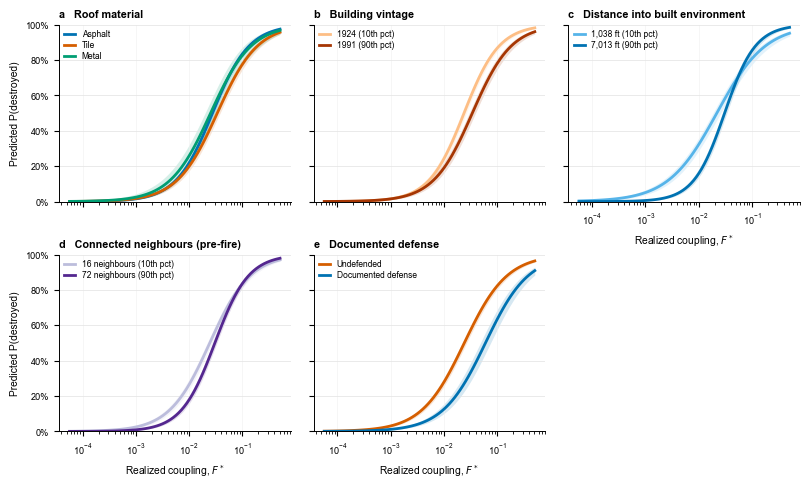

Panels a–d are the interaction model on exposed, undefended structures; panel e is the additive defense model, which retains defended structures. Curves hold the remaining covariates at their sample means for an asphalt roof in Eaton; bands are 95% cluster-robust intervals.
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_exposure_interactions.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from patsy import build_design_matrices

from src.viz.style import apply_style

fitted_by_key = dict((key, model) for key, _, _, model in FITTED_MODELS)
interaction_model = fitted_by_key['exposure_interactions']
defense_model = fitted_by_key['documented_defense']
exposure_grid = np.linspace(
    float(np.percentile(regression_sample.log_F_star, 2.5)),
    float(np.percentile(regression_sample.log_F_star, 97.5)), 80)
exposure_axis = np.exp(exposure_grid + CENTRING['log_F_star'])


def _predicted_probability(model, **overrides):
    """Predicted P(destroyed) with a cluster-robust 95% band."""
    scenario = pd.DataFrame({
        'log_F_star': exposure_grid,
        'roof_class': overrides.get('roof_class', 'Asphalt'),
        'log_ndvi': 0.,
        'year_decade': overrides.get('year_decade', 0.),
        'log_n_visible': overrides.get('log_n_visible', 0.),
        'log_influence_depth': overrides.get('log_influence_depth', 0.),
        'defended_structure': overrides.get('defended_structure', 0),
        'fire': 'EATON',
    })
    design = np.asarray(build_design_matrices(
        [model.model.data.design_info], scenario)[0])
    covariance = model.cov_params().to_numpy()
    linear = design @ model.params.to_numpy()
    standard_error = np.sqrt(np.einsum(
        'ij,jk,ik->i', design, covariance, design))
    def _logistic(values):
        return 1 / (1 + np.exp(-values))
    return (_logistic(linear), _logistic(linear - 1.96 * standard_error),
            _logistic(linear + 1.96 * standard_error))


def _percentile_pair(column, percentiles=DEPTH_PERCENTILES):
    return [float(np.percentile(regression_sample[column], percentile))
            for percentile in percentiles]


depth_low, depth_high = _percentile_pair('log_influence_depth')
vintage_old, vintage_new = _percentile_pair('year_decade')
surround_low, surround_high = _percentile_pair('log_n_visible')


def _vintage_year(centered):
    return (centered + CENTRING['year_decade']) * 10 + samples.year_reference


PANELS = [
    ('Roof material', interaction_model, [
        ('Asphalt', {'roof_class': 'Asphalt'}, '#0072B2'),
        ('Tile', {'roof_class': 'Tile'}, '#D55E00'),
        ('Metal', {'roof_class': 'Metal'}, '#009E73')]),
    ('Building vintage', interaction_model, [
        (f'{_vintage_year(vintage_old):.0f} (10th pct)',
         {'year_decade': vintage_old}, '#FDBE85'),
        (f'{_vintage_year(vintage_new):.0f} (90th pct)',
         {'year_decade': vintage_new}, '#A63603')]),
    ('Distance into built environment', interaction_model, [
        (f'{np.exp(depth_low + CENTRING["log_influence_depth"]):,.0f} ft '
         '(10th pct)', {'log_influence_depth': depth_low}, '#56B4E9'),
        (f'{np.exp(depth_high + CENTRING["log_influence_depth"]):,.0f} ft '
         '(90th pct)', {'log_influence_depth': depth_high}, '#0072B2')]),
    ('Connected neighbors (pre-fire)', interaction_model, [
        (f'{np.exp(surround_low + CENTRING["log_n_visible"]):,.0f} neighbors '
         '(10th pct)', {'log_n_visible': surround_low}, '#BCBDDC'),
        (f'{np.exp(surround_high + CENTRING["log_n_visible"]):,.0f} neighbors '
         '(90th pct)', {'log_n_visible': surround_high}, '#54278F')]),
    ('Documented defense', defense_model, [
        ('Undefended', {'defended_structure': 0}, '#D55E00'),
        ('Documented defense', {'defended_structure': 1}, '#0072B2')]),
]

apply_style()
fig, axes = plt.subplots(2, 3, figsize=(8.1, 4.9), sharex=True,
                         sharey=True)
prediction_rows = []
for panel_index, (panel_title, model, series) in enumerate(PANELS):
    ax = axes.flat[panel_index]
    for series_label, overrides, color in series:
        probability, lower, upper = _predicted_probability(model, **overrides)
        ax.fill_between(exposure_axis, lower, upper, color=color, alpha=.16,
                        linewidth=0)
        ax.plot(exposure_axis, probability, color=color, lw=2.0,
                label=series_label)
        prediction_rows.append(pd.DataFrame({
            'panel': panel_title, 'series': series_label,
            'F_star': exposure_axis, 'probability': probability,
            'ci_lo': lower, 'ci_hi': upper}))
    ax.set_xscale('log')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', color='#E2E2E2', lw=.5)
    ax.grid(axis='x', color='#EFEFEF', lw=.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=6.6)
    ax.text(0, 1.03, f'{"abcdef"[panel_index]}   {panel_title}',
            transform=ax.transAxes, fontsize=7.8, fontweight='bold',
            va='bottom')
    ax.legend(loc='upper left', fontsize=6.1, frameon=False,
              handlelength=1.3, borderpad=.1, labelspacing=.22)
axes.flat[len(PANELS)].set_visible(False)
for ax in list(axes[1, :2]) + [axes[0, 2]]:
    ax.set_xlabel('Realized coupling, $F^*$', fontsize=7.4)
    ax.tick_params(labelbottom=True)
for ax in axes[:, 0]:
    ax.set_ylabel('Predicted P(destroyed)', fontsize=7.4)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
fig.subplots_adjust(left=.075, right=.99, top=.93, bottom=.10,
                    wspace=.10, hspace=.30)

exposure_predictions = pd.concat(prediction_rows, ignore_index=True)
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
FIGURES.mkdir(parents=True, exist_ok=True)
exposure_predictions.to_csv(
    RESULTS / 'ED_fig_exposure_interactions_source.csv', index=False)
exposure_stem = FIGURES / 'ED_fig_exposure_interactions'
fig.savefig(exposure_stem.with_suffix('.pdf'), bbox_inches='tight',
            facecolor='white')
fig.savefig(exposure_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Panels a–d are the interaction model on exposed, undefended structures; '
      'panel e is the additive defense model, which retains defended '
      'structures. Curves hold the remaining covariates at their sample means '
      'for an asphalt roof in Eaton; bands are 95% cluster-robust intervals.')
print('saved', exposure_stem.with_suffix('.png'))

### Robustness: consistency between fires, and reported tolerance ratios

*Supplement — Supplementary Table S3.*

The first check asks whether the reported associations depend on pooling the
two fires: every attribute, the exposure slope and distance are interacted
with fire and the interactions are tested jointly on the cluster-robust
covariance, so a term is reported as consistent between fires when its
interaction is not distinguishable from zero. The second table converts the
reporting model into exposure-tolerance ratios on interpretable spans, an
interquartile range for the logged predictors rather than a log unit, which is
the form the results section quotes.

In [28]:
# Do the associations differ between the two fires? Every attribute, the
# exposure slope and distance are interacted with fire and tested jointly.
VARYING_TERMS = (f'log_F_star + {ROOF_TERM} + log_ndvi + year_decade '
                 f'+ {SITE_TERM} + {DEPTH_TERM}')
fire_heterogeneity_model = fit_clustered_logit(
    regression_sample,
    f'is_destroyed ~ {BASE_TERMS} + {DEPTH_TERM} + C(fire):({VARYING_TERMS})')
fire_interaction_terms = [term for term in fire_heterogeneity_model.params.index
                          if 'C(fire)' in term and ':' in term]
restriction = np.zeros((len(fire_interaction_terms),
                        len(fire_heterogeneity_model.params)))
for row, term in enumerate(fire_interaction_terms):
    restriction[row, list(
        fire_heterogeneity_model.params.index).index(term)] = 1
fire_joint_test = fire_heterogeneity_model.wald_test(restriction, scalar=True)
fire_heterogeneity = pd.DataFrame([{
    'term': term, 'term_label': _term_label(term.split(':', 1)[1]),
    'coefficient': float(fire_heterogeneity_model.params[term]),
    'cluster_robust_se': float(fire_heterogeneity_model.bse[term]),
    'p_value': float(fire_heterogeneity_model.pvalues[term]),
} for term in fire_interaction_terms])
fire_heterogeneity['consistent_between_fires'] = (
    fire_heterogeneity.p_value.ge(.05))

fire_heterogeneity.to_csv(
    RESULTS / 'tableS_construction_fire_heterogeneity.csv', index=False)

print(f'Fire interactions tested jointly: '
      f'chi2({len(fire_interaction_terms)}) = '
      f'{float(fire_joint_test.statistic):.1f}, '
      f'P = {float(fire_joint_test.pvalue):.4g}')
display(fire_heterogeneity.round(4))
print('saved', RESULTS / 'tableS_construction_fire_heterogeneity.csv')

Fire interactions tested jointly: chi2(10) = 72.3, P = 1.601e-11


,term,term_label,coefficient,cluster_robust_se,p_value,consistent_between_fires
0,"C(fire)[T.PALISADES]:C(roof_class, Treatment(""...",Combustible roof,-1.7171,0.7464,0.0214,False
1,"C(fire)[T.PALISADES]:C(roof_class, Treatment(""...",Concrete roof,0.1688,0.4419,0.7025,True
2,"C(fire)[T.PALISADES]:C(roof_class, Treatment(""...",Metal roof,-0.7233,0.3404,0.0336,False
3,"C(fire)[T.PALISADES]:C(roof_class, Treatment(""...",Other roof,-1.5035,0.9518,0.1142,True
4,"C(fire)[T.PALISADES]:C(roof_class, Treatment(""...",Tile roof,0.1605,0.1279,0.2093,True
5,C(fire)[T.PALISADES]:log_F_star,"Realized coupling, log F*",-0.2912,0.0540,0.0000,False
6,C(fire)[T.PALISADES]:log_ndvi,Log near-structure NDVI,-0.3580,0.2163,0.0980,True
7,C(fire)[T.PALISADES]:year_decade,"Building vintage, per decade newer",0.0465,0.0274,0.0894,True
8,C(fire)[T.PALISADES]:log_n_visible,Log connected neighbours (pre-fire),-0.3955,0.0869,0.0000,False
9,C(fire)[T.PALISADES]:log_influence_depth,Log distance into built environment,0.4440,0.1271,0.0005,False


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_construction_fire_heterogeneity.csv


### Standardized protective margins

*Supplement — Extended Data Fig. 6.*

ED03 reports the reduction in destruction probability associated with each
attribute across realized coupling. That margin is a contrast *within one
outcome*: at each value of $F^*$ the whole population is predicted twice, once
with the vulnerable attribute setting and once with the protective one, and the
two standardized probabilities are differenced. This cell repeats that
construction on the interaction model fitted here, which adds distance into the
built environment as a fourth contrast, with bands from draws of the
cluster-robust coefficient covariance.

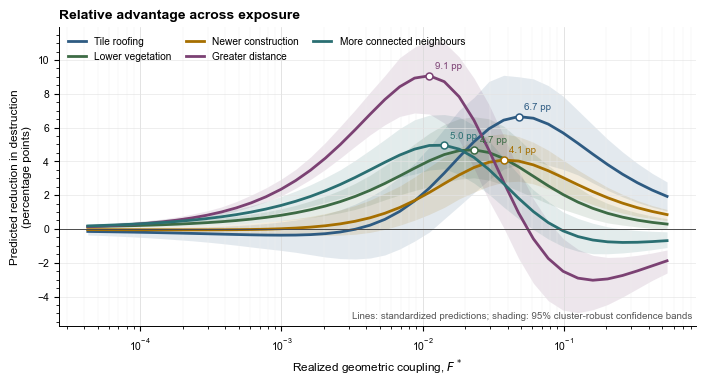

**Extended Data Figure | Standardized protective margins across realized coupling.** Predicted reduction in the probability of destruction associated with each contrast. At every value of $F^*$ the whole analysis population is predicted twice, once under the vulnerable setting and once under the protective setting, and the two standardized probabilities are differenced; the curves are therefore population-averaged contrasts within a single outcome, not differences between outcomes. Contrasts are tile rather than asphalt roofing, the 25th rather than the 75th percentile of near-structure NDVI, the 75th rather than the 25th percentile of construction year, and the 75th rather than the 25th percentile of distance into the built environment. Estimates come from the exposure-interaction model fitted to 21,283 exposed, undefended structures; shading gives 95% intervals from 200 draws of the cluster-robust coefficient covariance. Open circles mark each maximum. The burning-neighbour contrast differs in kind from the other four: the count is realized during the fire, like *F*\* itself, rather than a pre-fire characteristic that could be altered by siting or construction. Margins are near zero at low coupling, peak within the fragility transition and decline as destruction saturates; the distance contrast alone reverses sign, and distance is also the one covariate whose association differs between the two fires and does not survive restricting exposure to up-fire neighbours, so it should be read as exploratory.

,attribute,contrast,peak_margin_pp,peak_F_star,peak_exposure_percentile,margin_at_p98_pp
0,Tile roofing,Tile rather than asphalt,6.650,0.048,44.716,1.927
1,Lower vegetation,25th rather than 75th percentile NDVI,4.684,0.023,35.446,0.288
2,Newer construction,75th rather than 25th percentile year,4.079,0.038,41.122,0.849
3,Greater distance,75th rather than 25th percentile distance,9.069,0.011,28.708,-1.886
4,More connected neighbours,75th rather than 25th percentile connected nei...,4.957,0.014,30.818,-0.693


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_construction_margins.png


In [14]:
from matplotlib.ticker import LogFormatterMathtext
from scipy.special import expit

from src.viz.style import log_grid

MARGIN_GRID = 40
MARGIN_DRAWS = 200
MARGIN_SEED = 20250808

margin_grid = np.geomspace(
    float(np.exp(np.percentile(regression_sample.log_F_star, 2)
                 + CENTRING['log_F_star'])),
    float(np.exp(np.percentile(regression_sample.log_F_star, 98)
                 + CENTRING['log_F_star'])), MARGIN_GRID)
observed_F_star = np.exp(regression_sample.log_F_star
                         + CENTRING['log_F_star']).to_numpy()


def _standardized_probability(model, frame, overrides):
    """Average predicted probability over the population under one setting."""
    design = np.asarray(build_design_matrices(
        [model.model.data.design_info], frame.assign(**overrides),
        return_type='dataframe')[0])
    return design, expit(design @ np.asarray(model.params))


def _margin_curve(model, vulnerable, protective, draws):
    """Vulnerable-minus-protective margin in percentage points, with a band."""
    point, lower, upper = [], [], []
    for exposure in margin_grid:
        common = {'log_F_star': np.log(exposure) - CENTRING['log_F_star']}
        design_v, p_v = _standardized_probability(
            model, regression_sample, {**common, **vulnerable})
        design_p, p_p = _standardized_probability(
            model, regression_sample, {**common, **protective})
        point.append(100 * float(np.mean(p_v - p_p)))
        simulated = []
        for start in range(0, len(draws), 25):
            block = draws[start:start + 25]
            simulated.extend(100 * (expit(design_v @ block.T).mean(axis=0)
                                    - expit(design_p @ block.T).mean(axis=0)))
        low, high = np.percentile(simulated, [2.5, 97.5])
        lower.append(float(low)); upper.append(float(high))
    return np.array(point), np.array(lower), np.array(upper)


interaction_model = dict(
    (key, model) for key, _, _, model in FITTED_MODELS)['exposure_interactions']

rng = np.random.default_rng(MARGIN_SEED)
interaction_draws = rng.multivariate_normal(
    np.asarray(interaction_model.params),
    np.asarray(interaction_model.cov_params()), size=MARGIN_DRAWS,
    check_valid='ignore')

ndvi_low, ndvi_high = np.percentile(regression_sample.log_ndvi, [25, 75])
year_old, year_new = np.percentile(regression_sample.year_decade, [25, 75])
depth_near, depth_far = np.percentile(
    regression_sample.log_influence_depth, [25, 75])
surround_low, surround_high = np.percentile(
    regression_sample.log_n_visible, [25, 75])
MARGIN_CONTRASTS = {
    'Tile roofing': ({'roof_class': 'Asphalt'}, {'roof_class': 'Tile'},
                     'Tile rather than asphalt', '#2E5B82'),
    'Lower vegetation': ({'log_ndvi': ndvi_high}, {'log_ndvi': ndvi_low},
                         '25th rather than 75th percentile NDVI', '#3D6B45'),
    'Newer construction': ({'year_decade': year_old},
                           {'year_decade': year_new},
                           '75th rather than 25th percentile year', '#A66F00'),
    'Greater distance': ({'log_influence_depth': depth_near},
                         {'log_influence_depth': depth_far},
                         '75th rather than 25th percentile distance',
                         '#7B4173'),
    'More connected neighbors': ({'log_n_visible': surround_low},
                                  {'log_n_visible': surround_high},
                                  '75th rather than 25th percentile connected '
                                  'neighbors', '#2A6F72'),
}

margin_rows, margin_summary_rows = [], []
for attribute, (vulnerable, protective, contrast, _) in MARGIN_CONTRASTS.items():
    point, lower, upper = _margin_curve(
        interaction_model, vulnerable, protective, interaction_draws)
    peak = int(np.nanargmax(point))
    for index, exposure in enumerate(margin_grid):
        margin_rows.append({
            'attribute': attribute, 'contrast': contrast,
            'F_star': float(exposure), 'margin_pp': float(point[index]),
            'ci_lo': float(lower[index]), 'ci_hi': float(upper[index]),
            'exposure_percentile': float(
                100 * (observed_F_star <= exposure).mean())})
    margin_summary_rows.append({
        'attribute': attribute, 'contrast': contrast,
        'peak_margin_pp': float(point[peak]),
        'peak_F_star': float(margin_grid[peak]),
        'peak_exposure_percentile': float(
            100 * (observed_F_star <= margin_grid[peak]).mean()),
        'margin_at_p98_pp': float(point[-1])})
construction_margin_curves = pd.DataFrame(margin_rows)
construction_margin_summary = pd.DataFrame(margin_summary_rows)

construction_margin_curves.to_csv(
    RESULTS / 'ED_fig_construction_margins_source.csv', index=False)
construction_margin_summary.to_csv(
    RESULTS / 'tableS_construction_margin_summary.csv', index=False)

apply_style()
fig, ax = plt.subplots(figsize=(7.2, 4.15))
for attribute, (_, _, _, color) in MARGIN_CONTRASTS.items():
    block = (construction_margin_curves[
        construction_margin_curves.attribute.eq(attribute)]
        .sort_values('F_star'))
    ax.fill_between(block.F_star, block.ci_lo, block.ci_hi, color=color,
                    alpha=.13, linewidth=0)
    ax.plot(block.F_star, block.margin_pp, color=color, lw=2.0,
            label=attribute)
    peak = construction_margin_summary[
        construction_margin_summary.attribute.eq(attribute)].iloc[0]
    ax.plot(peak.peak_F_star, peak.peak_margin_pp, 'o', ms=5, color=color,
            mfc='white', mew=1.1, zorder=5)
    ax.annotate(f'{peak.peak_margin_pp:.1f} pp',
                (peak.peak_F_star, peak.peak_margin_pp), xytext=(4, 5),
                textcoords='offset points', fontsize=7, color=color)
ax.axhline(0, color='#4A4A4A', lw=.7)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.set_xlabel(r'Realized geometric coupling, $F^*$')
ax.set_ylabel('Predicted reduction in destruction\n(percentage points)')
ax.set_title('Relative advantage across exposure', loc='left', fontsize=10,
             fontweight='bold')
ax.text(.995, .02,
        'Lines: standardized predictions; shading: 95% cluster-robust '
        'confidence bands', transform=ax.transAxes, ha='right', va='bottom',
        fontsize=7, color='#555555')
log_grid(ax, axis='x')
ax.grid(True, axis='y', color='#E4E4E4', lw=.45)
ax.legend(frameon=False, loc='upper left', ncol=3, handlelength=1.8,
          columnspacing=1.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.subplots_adjust(left=.105, right=.99, top=.88, bottom=.16)
margin_stem = FIGURES / 'ED_fig_construction_margins'
fig.savefig(margin_stem.with_suffix('.pdf'), bbox_inches='tight',
            facecolor='white')
fig.savefig(margin_stem.with_suffix('.png'), dpi=400, bbox_inches='tight',
            facecolor='white')
plt.show()

margin_caption = (
    '**Extended Data Figure | Standardized protective margins across realized '
    'coupling.** Predicted reduction in the probability of destruction '
    'associated with each contrast. At every value of $F^*$ the whole analysis '
    'population is predicted twice, once under the vulnerable setting and once '
    'under the protective setting, and the two standardized probabilities are '
    'differenced; the curves are therefore population-averaged contrasts '
    'within a single outcome, not differences between outcomes. Contrasts are '
    'tile rather than asphalt roofing, the 25th rather than the 75th '
    'percentile of near-structure NDVI, the 75th rather than the 25th '
    'percentile of construction year, and the 75th rather than the 25th '
    'percentile of distance into the built environment. Estimates come from '
    f'the exposure-interaction model fitted to {len(regression_sample):,} '
    'exposed, undefended structures; shading gives 95% intervals from '
    f'{MARGIN_DRAWS} draws of the cluster-robust coefficient covariance. Open '
    'circles mark each maximum. The burning-neighbor contrast differs in '
    'kind from the other four: the count is realized during the fire, like '
    '*F*\\* itself, rather than a pre-fire characteristic that could be '
    'altered by siting or construction. Margins are near zero at low '
    'coupling, peak '
    'within the fragility transition and decline as destruction saturates; '
    'the distance contrast alone reverses sign, and distance is also the one '
    'covariate whose association differs between the two fires and does not '
    'survive restricting exposure to up-fire neighbors, so it should be read '
    'as exploratory.')
(RESULTS / 'ED_fig_construction_margins_caption.md').write_text(
    margin_caption + '\n', encoding='utf-8')

display(Markdown(margin_caption))
display(construction_margin_summary.round(3))
print('saved', margin_stem.with_suffix('.png'))

## Cross-fire sample and composition standardization

*Separate analysis — cross-fire composition standardization.*

The sample ladder separates the change associated with excluding defense from subsequent complete-data selection. On the complete sample, each fire's five-parameter fragility curve is refitted after reweighting its roof, age-cohort and vegetation distribution toward the other fire. The symmetric composition factor is the geometric mean of the two directional swaps. These are standardized comparisons, not causal components; factor-specific shares overlap and are not additive. Confidence intervals use 200 fire-stratified case-bootstrap refits, matching the prespecified analysis.

In [15]:
sample_ladder, standardization_table, standardization_draws = (
    cross_fire_standardization(
        samples, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
    )
)
sample_ladder.to_csv(RESULTS / 'cross_fire_sample_ladder.csv', index=False)
standardization_table.to_csv(
    RESULTS / 'cross_fire_standardization.csv', index=False
)
standardization_draws.to_csv(
    RESULTS / 'cross_fire_standardization_bootstrap.csv', index=False
)
display(sample_ladder.round(5))
display(standardization_table.round(4))

,sample,n,EATON_f50,PALISADES_f50,ratio_PAL_to_EAT
0,All exposed,25127,0.02284,0.03437,1.50511
1,Undefended,23835,0.02277,0.03162,1.38887
2,Undefended with known roof,21831,0.02520,0.03297,1.30812
3,"Complete roof, vegetation and vintage",21288,0.02532,0.03268,1.29071


,component,factor,ci_lo,ci_hi,share_of_log_gap_percent,successful_draws
0,raw,1.2907,1.1682,1.4491,NaN,200
1,materials,1.0196,0.9835,1.0606,7.6251,200
2,vegetation,1.0781,1.0513,1.1057,29.4641,200
3,full_stock,1.0817,1.0275,1.1321,30.7781,200
4,residual,1.1932,1.0508,1.3460,NaN,200
